# Housing Price Analysis Pipeline (Full Export)

In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier
)

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

# --- Path: Kaggle / lokal (jangan ubah struktur notebook di bawah) ---
import os
import zipfile
from pathlib import Path

IS_KAGGLE = os.path.exists('/kaggle/input')
if IS_KAGGLE:
    ROOT = Path('/kaggle/working')
    _candidates = list(Path('/kaggle/input').rglob('housing_price_dataset.csv'))
    DATA_PATH = _candidates[0] if _candidates else Path(
        '/kaggle/input/datasets/muhammadbinimran/housing-price-prediction-data/housing_price_dataset.csv'
    )
else:
    ROOT = Path('..').resolve()
    DATA_PATH = ROOT / 'dataset' / 'housing_price_dataset.csv'

MODEL_DIR = ROOT / 'model'
ASSETS_DIR = ROOT / 'assets'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
CURRENT_YEAR = 2026
print('ROOT:', ROOT)
print('DATA_PATH:', DATA_PATH)
print('MODEL_DIR:', MODEL_DIR)
print('ASSETS_DIR:', ASSETS_DIR)

ROOT: /kaggle/working
DATA_PATH: /kaggle/input/datasets/muhammadbinimran/housing-price-prediction-data/housing_price_dataset.csv
MODEL_DIR: /kaggle/working/model
ASSETS_DIR: /kaggle/working/assets


In [2]:

df = pd.read_csv(DATA_PATH)

location_map = {'Rural':0,'Suburb':1,'Urban':2}
df['NeighborhoodMap'] = df['Neighborhood'].map(location_map)

print(df.shape)
display(df.head())


(50000, 7)


,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,NeighborhoodMap
0,2126,4,1,Rural,1969,215355.283618,0
1,2459,3,2,Rural,1980,195014.221626,0
2,1860,2,1,Suburb,1970,306891.012076,1
3,2294,2,1,Urban,1996,206786.787153,2
4,2130,5,2,Suburb,2001,272436.239065,1


## EDA

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SquareFeet       50000 non-null  int64  
 1   Bedrooms         50000 non-null  int64  
 2   Bathrooms        50000 non-null  int64  
 3   Neighborhood     50000 non-null  object 
 4   YearBuilt        50000 non-null  int64  
 5   Price            50000 non-null  float64
 6   NeighborhoodMap  50000 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 2.7+ MB


SquareFeet         0
Bedrooms           0
Bathrooms          0
Neighborhood       0
YearBuilt          0
Price              0
NeighborhoodMap    0
dtype: int64

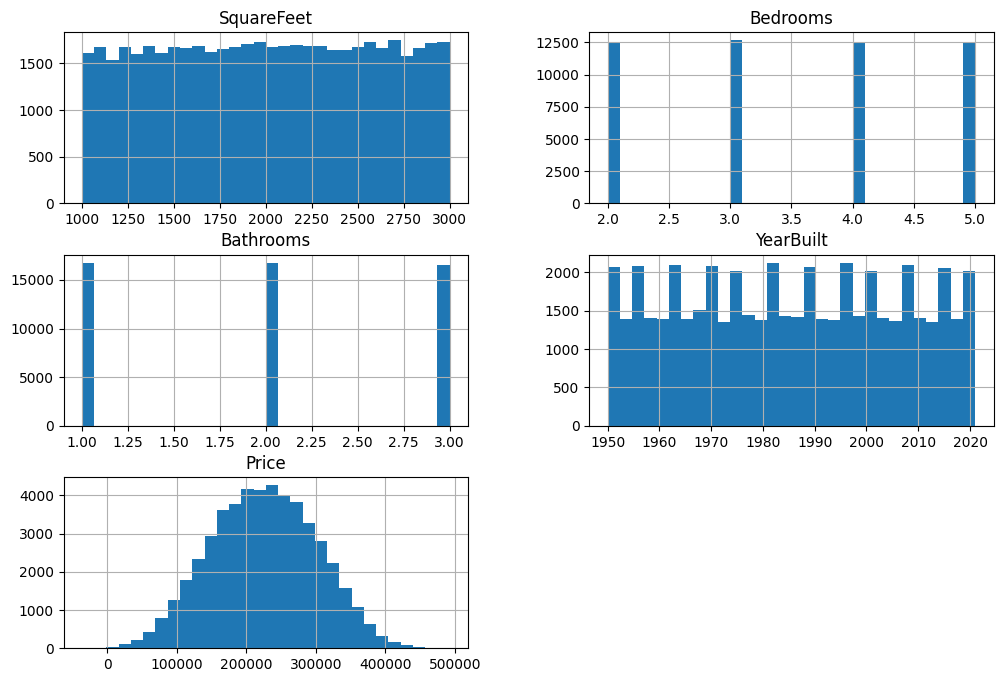

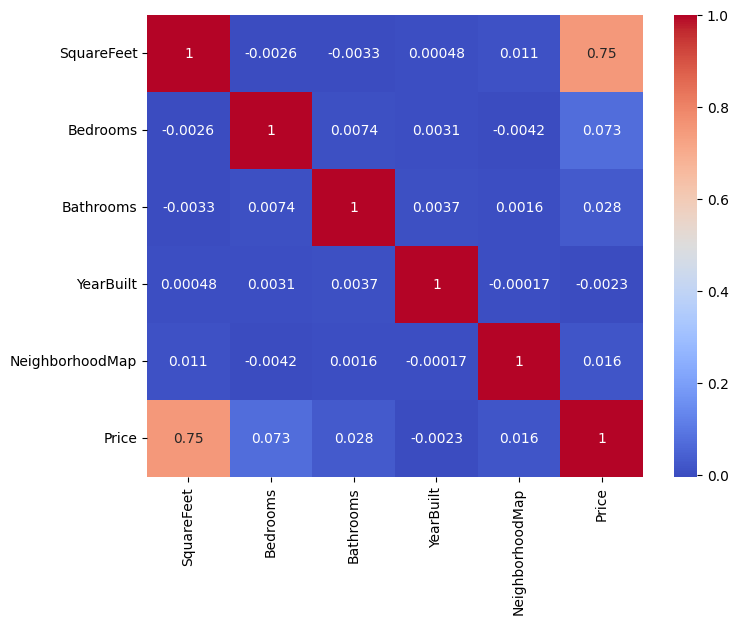

In [4]:
num_cols=['SquareFeet','Bedrooms','Bathrooms','YearBuilt','Price']
df[num_cols].hist(figsize=(12,8),bins=30)
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[['SquareFeet','Bedrooms','Bathrooms','YearBuilt','NeighborhoodMap','Price']].corr(),annot=True,cmap='coolwarm')
plt.show()


## Regression

In [5]:
# House age
CURRENT_YEAR = 2026
df['HouseAge'] = CURRENT_YEAR - df['YearBuilt']

# Area per bedroom
df['AreaPerBedroom'] = (
    df['SquareFeet'] /
    (df['Bedrooms'] + 1)
)

# Area per bathroom
df['AreaPerBathroom'] = (
    df['SquareFeet'] /
    (df['Bathrooms'] + 1)
)

# Bathroom ratio
df['BathPerBedroom'] = (
    df['Bathrooms'] /
    (df['Bedrooms'] + 1)
)

# One Hot Encoding
df = pd.get_dummies(
    df,
    columns=['Neighborhood'],
    drop_first=True
)

In [6]:
feature_cols = [
    'SquareFeet',
    'Bedrooms',
    'Bathrooms',
    'YearBuilt',
    'HouseAge',
    'AreaPerBedroom',
    'AreaPerBathroom',
    'BathPerBedroom'
]

feature_cols += [
    col for col in df.columns
    if col.startswith('Neighborhood_')
]

X = df[feature_cols]
y = df['Price']

In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_grid = {
    'n_estimators':[300,500],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

rf_search = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    rf_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train,y_train)

rf_best = rf_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [9]:
from xgboost import XGBRegressor

xgb_grid = {
    'n_estimators':[500,1000],
    'max_depth':[4,6,8],
    'learning_rate':[0.01,0.05,0.1]
}

xgb_search = GridSearchCV(
    XGBRegressor(
        random_state=42
    ),
    xgb_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(
    X_train,
    y_train
)

xgb_best = xgb_search.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits


In [10]:
from lightgbm import LGBMRegressor

lgb_grid = {
    'num_leaves':[31,63,127],
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':[500,1000]
}

lgb_search = GridSearchCV(
    LGBMRegressor(
        random_state=42
    ),
    lgb_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

lgb_search.fit(
    X_train,
    y_train
)

lgb_best = lgb_search.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000751 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 10
[LightGBM] [Info] Start training from score 224398.369886
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017269 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 10
[LightGBM] [Info] Start training from score 225089.329182
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003590 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not 

In [11]:
from catboost import CatBoostRegressor

cat_grid = {
    'depth':[4,6,8],
    'learning_rate':[0.01,0.05,0.1],
    'iterations':[500,1000]
}

cat_search = GridSearchCV(
    CatBoostRegressor(
        verbose=0,
        random_state=42
    ),
    cat_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

cat_search.fit(
    X_train,
    y_train
)

cat_best = cat_search.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits


In [12]:
models = {
    'Linear Regression':LinearRegression(),
    'Random Forest':rf_best,
    'XGBoost':xgb_best,
    'LightGBM':lgb_best,
    'CatBoost':cat_best
}

In [13]:
results=[]

best_model=None
best_r2=-999

for name,model in models.items():

    model.fit(
        X_train,
        y_train
    )

    pred=model.predict(X_test)

    mae=mean_absolute_error(
        y_test,
        pred
    )

    rmse=np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2=r2_score(
        y_test,
        pred
    )

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

    if r2 > best_r2:

        best_r2 = r2
        best_model = model

regression_results = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2'
    ]
).sort_values(
    'R2',
    ascending=False
)

display(regression_results)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 10
[LightGBM] [Info] Start training from score 224795.672923


,Model,MAE,RMSE,R2
0,Linear Regression,39433.385349,49357.109297,0.575585
4,CatBoost,39433.606055,49368.630379,0.575387
2,XGBoost,39427.053866,49394.423921,0.574943
3,LightGBM,39434.735450,49416.933349,0.574555
1,Random Forest,39660.292728,49714.778260,0.569411


In [14]:
import pickle

with open(
    MODEL_DIR / 'prediction.pkl',
    'wb'
) as f:

    pickle.dump(
        best_model,
        f
    )

<class 'float'>
object
(10000, 10)
float64
(10000, 10)


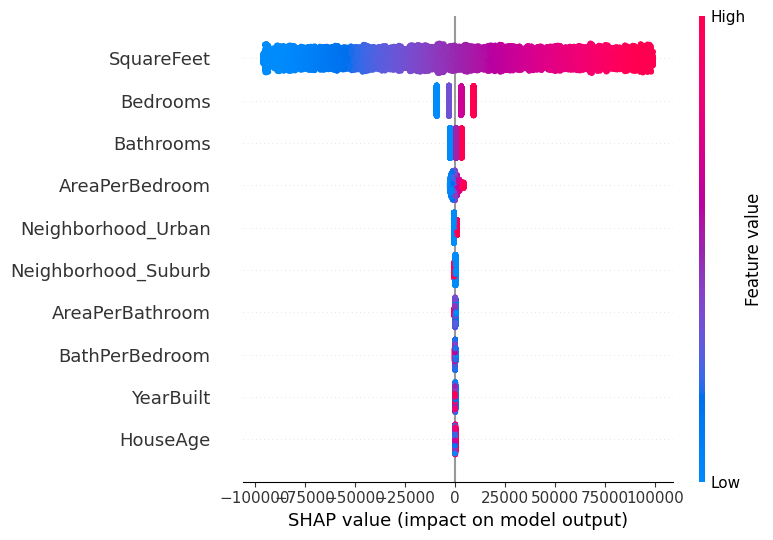

In [15]:
import shap

explainer = shap.Explainer(
    best_model,
    X_train
)

X_test_shap = X_test.astype(float)



shap_values = explainer(X_test_shap)
print(type(shap_values.values[0,0]))
print(shap_values.values.dtype)
print(shap_values.values.shape)

shap_array = np.array(
    shap_values.values.tolist(),
    dtype=np.float64
)

print(shap_array.dtype)
print(shap_array.shape)

X_test_float = X_test.astype(np.float64)

shap.summary_plot(
    shap_array,
    X_test_float
)

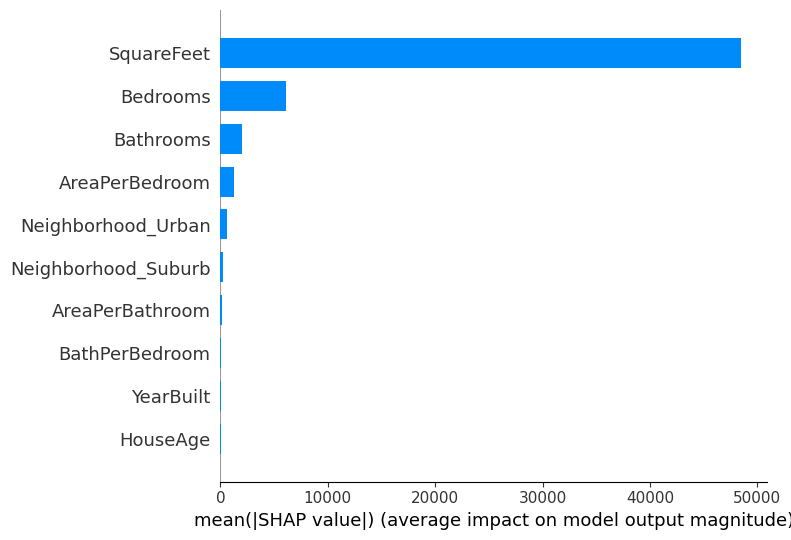

In [16]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

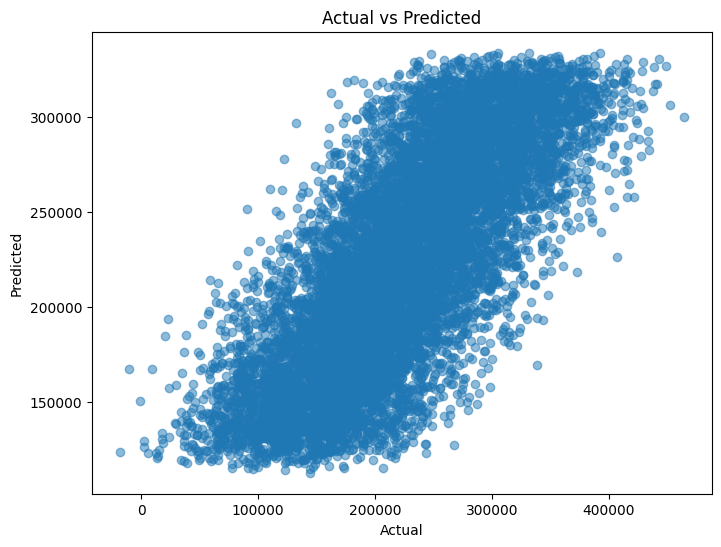

In [17]:
best_pred = best_model.predict(
    X_test
)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.5
)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')

plt.show()

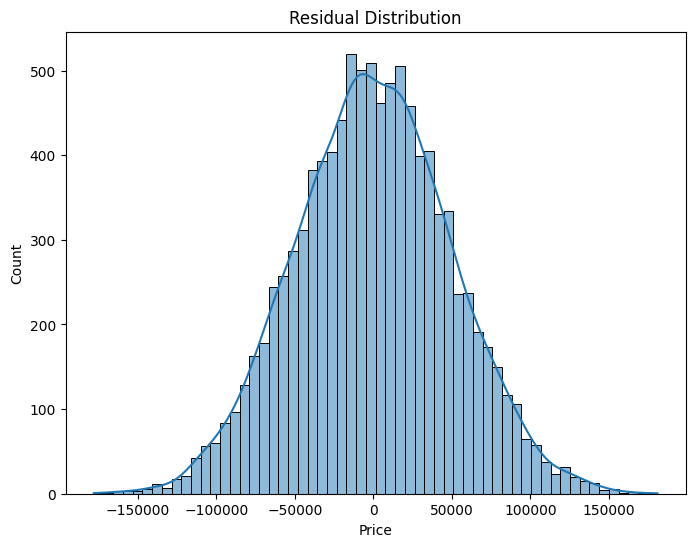

In [18]:
residuals = y_test - best_pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    'Residual Distribution'
)

plt.show()

## Classification

In [19]:
df['PriceCategory'] = pd.qcut(
    df['Price'],
    q=2,
    labels=[
        'Low',
        'High'
    ]
)

In [20]:
feature_cols = [
    'SquareFeet',
    'Bedrooms',
    'Bathrooms',
    'YearBuilt',
    'HouseAge',
    'AreaPerBedroom',
    'AreaPerBathroom',
    'BathPerBedroom'
]

feature_cols += [
    col for col in df.columns
    if col.startswith('Neighborhood_')
]

In [21]:
X = df[feature_cols]
y = df['PriceCategory']

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(
    df['PriceCategory']
)

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_grid = {
    'C':[0.01,0.1,1,10,100]
}

log_search = GridSearchCV(
    LogisticRegression(
        max_iter=10000
    ),
    log_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

log_search.fit(
    X_train,
    y_train
)

log_best = log_search.best_estimator_

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_grid = {
    'n_estimators':[300,500],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

rf_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    rf_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_search.fit(
    X_train,
    y_train
)

rf_best = rf_search.best_estimator_

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 10
[LightGBM] [Info] Start training from score 224799.304722
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 10
[LightGBM] [Info] Start training from score 224799.304722
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] 

In [24]:
from xgboost import XGBClassifier

xgb_grid = {
    'n_estimators':[500,1000],
    'max_depth':[4,6,8],
    'learning_rate':[0.01,0.05,0.1]
}

xgb_search = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    ),
    xgb_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_search.fit(
    X_train,
    y_train
)

xgb_best = xgb_search.best_estimator_

In [25]:
from lightgbm import LGBMClassifier

lgb_grid = {
    'num_leaves':[31,63,127],
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':[500,1000]
}

lgb_search = GridSearchCV(
    LGBMClassifier(
        random_state=42
    ),
    lgb_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

lgb_search.fit(
    X_train,
    y_train
)

lgb_best = lgb_search.best_estimator_

[LightGBM] [Info] Number of positive: 16000, number of negative: 16000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001031 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 16000, number of negative: 16000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023660 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 16000, number of negat

In [26]:
from catboost import CatBoostClassifier

cat_grid = {
    'depth':[4,6,8],
    'learning_rate':[0.01,0.05,0.1],
    'iterations':[500,1000]
}

cat_search = GridSearchCV(
    CatBoostClassifier(
        verbose=0,
        random_state=42
    ),
    cat_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

cat_search.fit(
    X_train,
    y_train
)

cat_best = cat_search.best_estimator_

In [27]:
models = {
    'Logistic':log_best,
    'RandomForest':rf_best,
    'XGBoost':xgb_best,
    'LightGBM':lgb_best,
    'CatBoost':cat_best
}

results=[]

best_classifier=None
best_acc=0

In [28]:
for name,model in models.items():

    model.fit(
        X_train,
        y_train
    )

    pred=model.predict(
        X_test
    )

    acc=accuracy_score(
        y_test,
        pred
    )

    precision=precision_score(
        y_test,
        pred,
        average='weighted'
    )

    recall=recall_score(
        y_test,
        pred,
        average='weighted'
    )

    f1=f1_score(
        y_test,
        pred,
        average='weighted'
    )

    results.append([
        name,
        acc,
        precision,
        recall,
        f1
    ])

    if acc > best_acc:

        best_acc = acc
        best_classifier = model

[LightGBM] [Info] Number of positive: 20000, number of negative: 20000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000561 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [29]:
classification_results = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1'
    ]
).sort_values(
    'Accuracy',
    ascending=False
)

display(
    classification_results
)

,Model,Accuracy,Precision,Recall,F1
4,CatBoost,0.8039,0.803915,0.8039,0.803898
0,Logistic,0.8030,0.803014,0.8030,0.802998
2,XGBoost,0.8028,0.802808,0.8028,0.802799
3,LightGBM,0.8028,0.802802,0.8028,0.802800
1,RandomForest,0.8020,0.802030,0.8020,0.801995


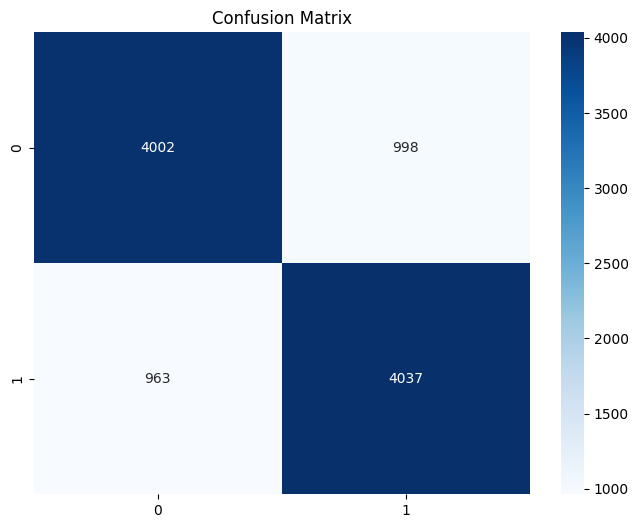

In [30]:
best_pred = best_classifier.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix'
)

plt.show()

In [31]:
import shap

explainer = shap.TreeExplainer(
    best_classifier
)

shap_values = explainer.shap_values(
    X_test
)

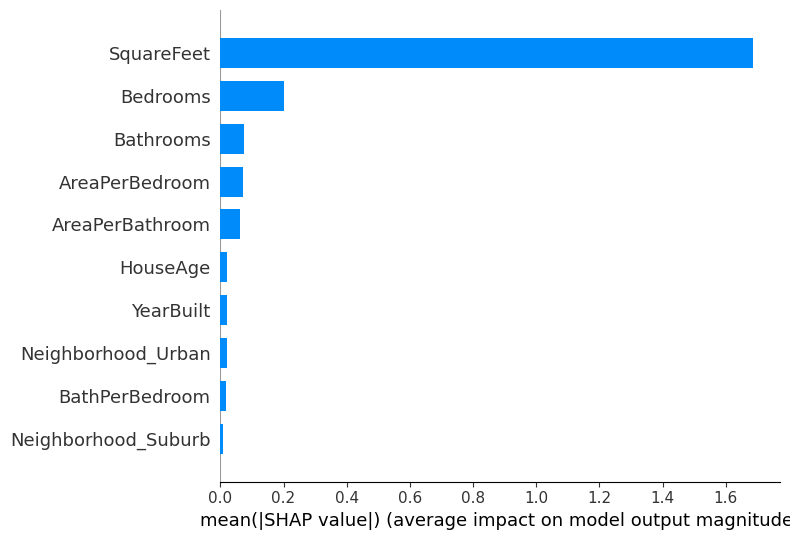

In [32]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)



In [33]:
import pickle

with open(
    MODEL_DIR / 'classification.pkl',
    'wb'
) as f:

    pickle.dump(
        best_classifier,
        f
    )

with open(MODEL_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Saved:', MODEL_DIR / 'classification.pkl', MODEL_DIR / 'label_encoder.pkl')

Saved: /kaggle/working/model/classification.pkl /kaggle/working/model/label_encoder.pkl


## Clustering

In [34]:
cluster_features = [
    'SquareFeet',
    'Bedrooms',
    'Bathrooms',
    'HouseAge',
    'AreaPerBedroom',
    'AreaPerBathroom',
    'BathPerBedroom',
    'Price'
]

cluster_features += [
    col for col in df.columns
    if col.startswith('Neighborhood_')
]

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    df[cluster_features]
)

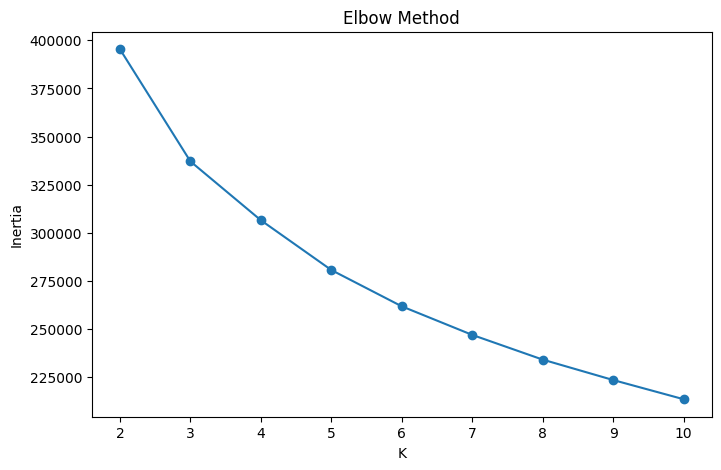

In [36]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    km.fit(X_cluster)

    inertia.append(
        km.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [37]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(
        X_cluster
    )

    score = silhouette_score(
        X_cluster,
        labels
    )

    scores.append([
        k,
        score
    ])

sil_df = pd.DataFrame(
    scores,
    columns=[
        'K',
        'Silhouette'
    ]
)

display(
    sil_df.sort_values(
        'Silhouette',
        ascending=False
    )
)

,K,Silhouette
0,2,0.189359
1,3,0.181535
5,7,0.173032
8,10,0.170917
4,6,0.170690
7,9,0.168060
6,8,0.167927
3,5,0.165948
2,4,0.155229


In [38]:
best_k = sil_df.sort_values(
    'Silhouette',
    ascending=False
).iloc[0]['K']

best_k = int(best_k)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(
    X_cluster
)

In [39]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=best_k
)

agg_labels = agg.fit_predict(
    X_cluster
)


[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 16000, number of negative: 16000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000591 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 16000, number of negative: 16000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 935
[LightGBM] [Info] Number o

In [40]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=best_k,
    random_state=42
)

gmm_labels = gmm.fit_predict(
    X_cluster
)

In [41]:
from sklearn.cluster import DBSCAN

dbscan_results = []

for eps in [0.3,0.5,0.7,1.0,1.2]:

    for ms in [5,10,15]:

        db = DBSCAN(
            eps=eps,
            min_samples=ms
        )

        labels = db.fit_predict(
            X_cluster
        )

        n_clusters = len(
            set(labels)
        ) - (
            1 if -1 in labels else 0
        )

        if n_clusters > 1:

            score = silhouette_score(
                X_cluster,
                labels
            )

            dbscan_results.append([
                eps,
                ms,
                n_clusters,
                score
            ])

In [42]:
dbscan_results = pd.DataFrame(
    dbscan_results,
    columns=[
        'eps',
        'min_samples',
        'clusters',
        'silhouette'
    ]
)

display(
    dbscan_results.sort_values(
        'silhouette',
        ascending=False
    )
)

,eps,min_samples,clusters,silhouette
12,1.2,5,15,0.116214
14,1.2,15,15,0.116214
13,1.2,10,15,0.116214
9,1.0,5,27,0.104918
10,1.0,10,27,0.104908
11,1.0,15,27,0.104854
6,0.7,5,36,0.090189
7,0.7,10,36,0.089486
8,0.7,15,36,0.088267
4,0.5,10,36,0.070890


In [43]:
cluster_results = pd.DataFrame({

    'Method':[
        'KMeans',
        'Agglomerative',
        'GMM'
    ],

    'Num_Clusters':[

        len(set(kmeans_labels)),
        len(set(agg_labels)),
        len(set(gmm_labels))

    ],

    'Silhouette_Score':[

        silhouette_score(
            X_cluster,
            kmeans_labels
        ),

        silhouette_score(
            X_cluster,
            agg_labels
        ),

        silhouette_score(
            X_cluster,
            gmm_labels
        )
    ]

}).sort_values(
    'Silhouette_Score',
    ascending=False
)

display(cluster_results)

,Method,Num_Clusters,Silhouette_Score
0,KMeans,2,0.189359
2,GMM,2,0.173690
1,Agglomerative,2,0.140011


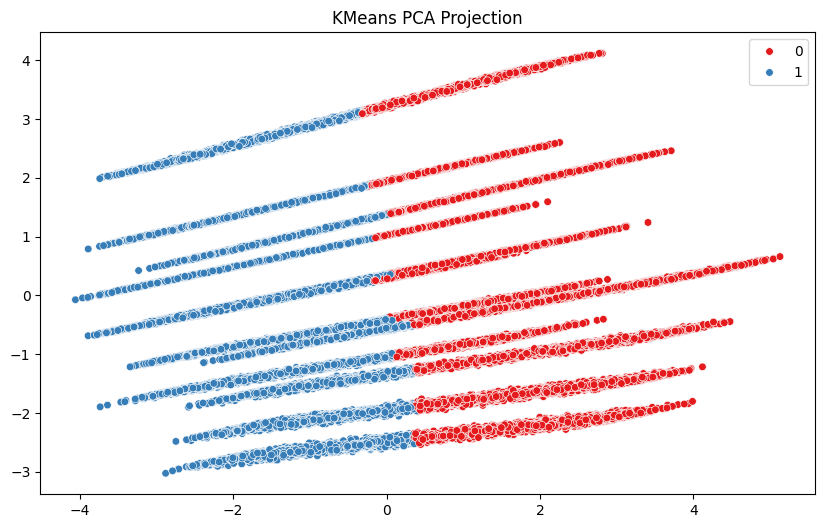

In [44]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_cluster
)

plt.figure(
    figsize=(10,6)
)

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=kmeans_labels,
    palette='Set1',
    s=30
)

plt.title(
    'KMeans PCA Projection'
)

plt.show()

In [45]:
df['Cluster'] = kmeans_labels

In [46]:
cluster_profile = df.groupby(
    'Cluster'
)[
    cluster_features
].mean()

display(
    cluster_profile
)

,SquareFeet,Bedrooms,Bathrooms,HouseAge,AreaPerBedroom,AreaPerBathroom,BathPerBedroom,Price,Neighborhood_Suburb,Neighborhood_Urban
Cluster,,,,,,,,,,
0,2495.254607,3.361493,1.834352,40.538155,608.832216,944.584897,0.451136,278178.774178,0.328866,0.339881
1,1559.563428,3.624100,2.142627,40.648063,355.838049,525.783890,0.493980,176066.829171,0.339496,0.324912


In [47]:
cluster_profile[['Price']]

,Price
Cluster,
0,278178.774178
1,176066.829171


In [48]:
profile = df.groupby(
    'Cluster'
)[
    [
        'SquareFeet',
        'Bedrooms',
        'Bathrooms',
        'HouseAge',
        'Price'
    ]
].mean()

In [49]:
from sklearn.preprocessing import MinMaxScaler

radar_data = MinMaxScaler().fit_transform(
    profile
)

In [50]:
cluster_profile

,SquareFeet,Bedrooms,Bathrooms,HouseAge,AreaPerBedroom,AreaPerBathroom,BathPerBedroom,Price,Neighborhood_Suburb,Neighborhood_Urban
Cluster,,,,,,,,,,
0,2495.254607,3.361493,1.834352,40.538155,608.832216,944.584897,0.451136,278178.774178,0.328866,0.339881
1,1559.563428,3.624100,2.142627,40.648063,355.838049,525.783890,0.493980,176066.829171,0.339496,0.324912


In [51]:
feature_importance = pd.DataFrame({
    'Feature':cluster_features,
    'Std':df[cluster_features].std()
})

In [52]:
import pickle

with open(
    MODEL_DIR / 'clustering.pkl',
    'wb'
) as f:

    pickle.dump(
        kmeans,
        f
    )

with open(
    MODEL_DIR / 'cluster_scaler.pkl',
    'wb'
) as f:

    pickle.dump(
        scaler,
        f
    )

print('Saved:', MODEL_DIR / 'clustering.pkl', MODEL_DIR / 'cluster_scaler.pkl')

Saved: /kaggle/working/model/clustering.pkl /kaggle/working/model/cluster_scaler.pkl


## Export Assets + Zip (Flask / pengumpulan UAS)

Cell ini menyimpan CSV metrik, profil cluster, grafik utama, dan **`uas_artifacts.zip`** (`model/` + `assets/`).

In [53]:
import json

# CSV hasil evaluasi
regression_results.to_csv(ASSETS_DIR / 'regression_results.csv', index=False)
classification_results.to_csv(ASSETS_DIR / 'classification_results.csv', index=False)
cluster_profile.reset_index().to_csv(ASSETS_DIR / 'cluster_profile.csv', index=False)

# Ringkasan metrik untuk app/config.py
best_reg_row = regression_results.iloc[0]
best_cls_row = classification_results.sort_values('Accuracy', ascending=False).iloc[0]
metrics_summary = {
    'regression': {
        'model': str(best_reg_row['Model']),
        'r2': float(best_reg_row['R2']),
        'mae': float(best_reg_row['MAE']),
        'rmse': float(best_reg_row['RMSE']),
    },
    'classification': {
        'model': str(best_cls_row['Model']),
        'accuracy': float(best_cls_row['Accuracy']),
        'f1': float(best_cls_row.get('F1', best_cls_row['Accuracy'])),
    },
    'clustering': {
        'model': 'K-Means',
        'n_clusters': int(best_k),
        'silhouette': float(sil_df['Silhouette'].max()),
    },
}
with open(ASSETS_DIR / 'metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)
print(json.dumps(metrics_summary, indent=2))

{
  "regression": {
    "model": "Linear Regression",
    "r2": 0.5755846634010977,
    "mae": 39433.38534940606,
    "rmse": 49357.10929741986
  },
  "classification": {
    "model": "CatBoost",
    "accuracy": 0.8039,
    "f1": 0.8038975977455725
  },
  "clustering": {
    "model": "K-Means",
    "n_clusters": 2,
    "silhouette": 0.18935888904608875
  }
}


In [54]:
# Grafik utama ke assets/ (untuk halaman Visualization Flask)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, ax=ax, color='#2563eb')
ax.set_title('Distribusi Harga')
fig.savefig(ASSETS_DIR / 'price_distribution.png', dpi=120, bbox_inches='tight')
plt.close()

raw = pd.read_csv(DATA_PATH)
fig, ax = plt.subplots(figsize=(6, 4))
raw['Neighborhood'].value_counts().plot(kind='bar', ax=ax)
fig.savefig(ASSETS_DIR / 'neighborhood_counts.png', dpi=120, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(raw.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', ax=ax)
fig.savefig(ASSETS_DIR / 'correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.close()

if hasattr(best_model, 'coef_'):
    imp = pd.Series(best_model.coef_, index=feature_cols).sort_values()
    fig, ax = plt.subplots(figsize=(8, 5))
    imp.plot(kind='barh', ax=ax)
    fig.savefig(ASSETS_DIR / 'regression_coefficients.png', dpi=120, bbox_inches='tight')
    plt.close()

sample = df.sample(min(3000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
cl = sample['Cluster'] if 'Cluster' in sample.columns else kmeans.predict(scaler.transform(sample[cluster_features]))
sc = ax.scatter(sample['SquareFeet'], sample['Price'], c=cl, cmap='viridis', alpha=0.5, s=10)
plt.colorbar(sc, ax=ax)
fig.savefig(ASSETS_DIR / 'cluster_scatter.png', dpi=120, bbox_inches='tight')
plt.close()

print('Assets PNG tersimpan di', ASSETS_DIR)

Assets PNG tersimpan di /kaggle/working/assets


In [55]:
# SHAP → assets (bonus Explainable AI)
X_shap = X_test.sample(min(500, len(X_test)), random_state=42)
explainer = shap.Explainer(best_model, X_shap)
sv = explainer(X_shap.astype(float))
plt.figure(figsize=(10, 6))
shap.summary_plot(np.array(sv.values.tolist(), dtype=float), X_shap, show=False)
plt.savefig(ASSETS_DIR / 'shap_regression.png', dpi=120, bbox_inches='tight')
plt.close()

explainer_c = shap.TreeExplainer(best_classifier)
sv_c = explainer_c.shap_values(X_shap)
plt.figure(figsize=(10, 6))
shap.summary_plot(sv_c, X_shap, plot_type='bar', show=False)
plt.savefig(ASSETS_DIR / 'shap_classification.png', dpi=120, bbox_inches='tight')
plt.close()
print('SHAP assets OK')

SHAP assets OK


In [56]:
ZIP_PATH = ROOT / 'uas_artifacts.zip'
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for folder, label in [(MODEL_DIR, 'model'), (ASSETS_DIR, 'assets')]:
        for fp in folder.rglob('*'):
            if fp.is_file():
                zf.write(fp, f"{label}/{fp.relative_to(folder)}")

print('ZIP:', ZIP_PATH, f'({ZIP_PATH.stat().st_size / 1024 / 1024:.2f} MB)')
print('model/:', [p.name for p in MODEL_DIR.iterdir()])
print('assets/:', [p.name for p in ASSETS_DIR.iterdir()])
print('\nLokal: extract model/ -> UAS/model/, assets/ -> UAS/app/static/assets/')
print('         cluster_profile.csv juga ke UAS/app/static/data/')

ZIP: /kaggle/working/uas_artifacts.zip (0.53 MB)
model/: ['label_encoder.pkl', 'prediction.pkl', 'cluster_scaler.pkl', 'classification.pkl', 'clustering.pkl']
assets/: ['classification_results.csv', 'correlation_heatmap.png', 'neighborhood_counts.png', 'shap_regression.png', 'shap_classification.png', 'metrics_summary.json', 'cluster_profile.csv', 'regression_coefficients.png', 'regression_results.csv', 'cluster_scatter.png', 'price_distribution.png']

Lokal: extract model/ -> UAS/model/, assets/ -> UAS/app/static/assets/
         cluster_profile.csv juga ke UAS/app/static/data/
